## Global-Only Dashboard (Emotion + Relationship)

- 모든 에피소드를 `global_turn`으로 이어서 봅니다.
- 점선/라벨로 에피소드 경계를 표시합니다.
- 수민(또는 지정 캐릭터) 관점의 관계 변화를 함께 봅니다.

default_episode_ids (latest per epXX): ['ep01_conference_shadow', 'ep02_rival_and_ghosts', 'ep03_unexpected_visitors', 'ep04_patrons_doctrine', 'ep05_between_faction', 'ep06_nsa_briefing', 'ep07_opening', 'ep08_personal_risk', 'ep09_conflict_meeting', 'ep10_cartel_shadow']
latest_episode_id: ep10_cartel_shadow
episodes included: ep01_conference_shadow, ep02_rival_and_ghosts, ep03_unexpected_visitors, ep04_patrons_doctrine, ep05_between_faction, ep06_nsa_briefing, ep07_opening, ep08_personal_risk, ep09_conflict_meeting, ep10_cartel_shadow


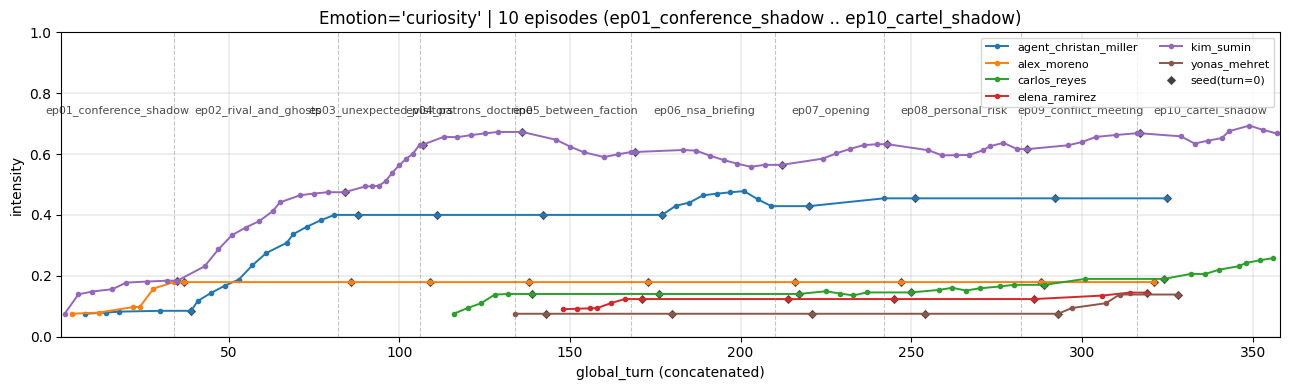

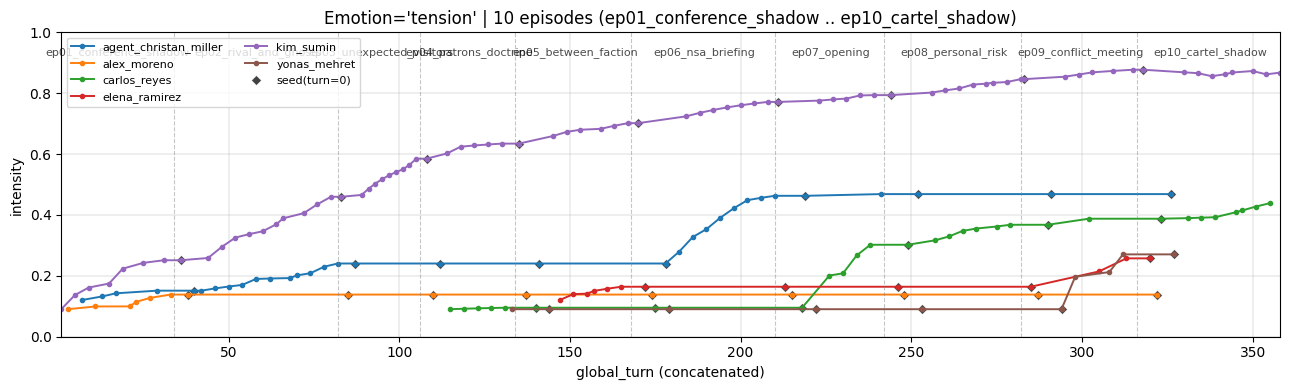

                other_id  updates  episodes  min_value  max_value  last_value
2           carlos_reyes       42         5      -1.00      -0.50       -1.00
0  agent_christan_miller       40         3      -0.70       0.05        0.05
3          elena_ramirez       12         1       0.65       1.00        1.00
4           yonas_mehret        8         2      -0.05       0.25        0.25
1             ben_clarke        1         1      -0.25      -0.25       -0.25
episodes included: ep01_conference_shadow, ep02_rival_and_ghosts, ep04_patrons_doctrine, ep05_between_faction, ep06_nsa_briefing, ep07_opening, ep08_personal_risk, ep09_conflict_meeting, ep10_cartel_shadow


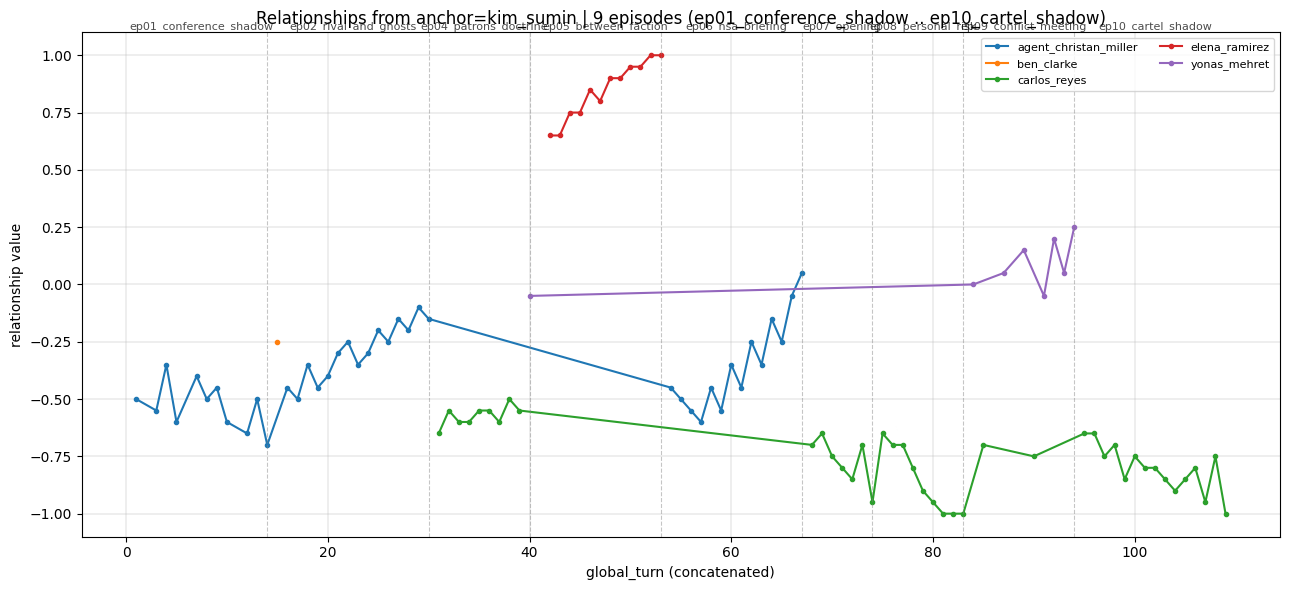

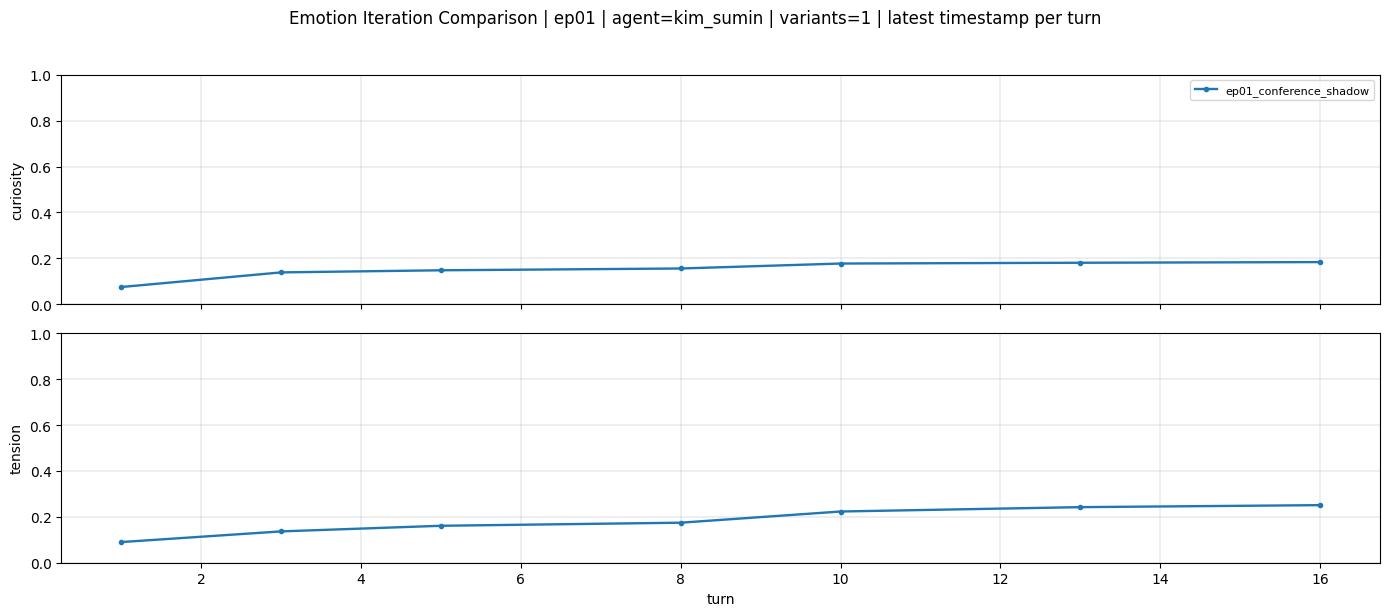

In [17]:
from pathlib import Path
import re
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

DB_PATH = Path('/Users/saesunkim/Documents/Novel Writter - 2026/data/simulation.db')
assert DB_PATH.exists(), f"DB not found: {DB_PATH}"
conn = sqlite3.connect(DB_PATH)


def q(sql, params=None):
    return pd.read_sql_query(sql, conn, params=params or {})

def load_recent_created_episode_ids(n: int | None = None, same_day: bool = True, only_complete: bool = True) -> list[str]:
    """Return most recently created episode IDs (optionally all from latest creation day)."""
    where = ["1=1"]
    if only_complete:
        where.append("status = 'complete'")
    where_sql = " AND ".join(where)

    if same_day:
        sql = f"""
        WITH e AS (
            SELECT id, COALESCE(end_time, start_time) AS ts
            FROM episodes
            WHERE {where_sql}
        ), latest_day AS (
            SELECT substr(MAX(ts), 1, 10) AS d FROM e
        )
        SELECT id
        FROM e, latest_day
        WHERE substr(ts, 1, 10) = latest_day.d
        ORDER BY ts
        """
        return q(sql)['id'].tolist()

    limit_sql = f" LIMIT {int(n)}" if n else ""
    sql = f"""
    SELECT id
    FROM episodes
    WHERE {where_sql}
    ORDER BY COALESCE(end_time, start_time) DESC
    {limit_sql}
    """
    ids = q(sql)['id'].tolist()
    ids.reverse()  # oldest -> newest for plotting continuity
    return ids


def load_latest_created_episode_id(only_complete: bool = True) -> str | None:
    ids = load_recent_created_episode_ids(n=1, same_day=False, only_complete=only_complete)
    return ids[-1] if ids else None


def _filter_episode_ids(df: pd.DataFrame, episode_ids: list[str] | None = None) -> pd.DataFrame:
    if df.empty or not episode_ids:
        return df
    keep = set(episode_ids)
    return df[df['episode_id'].isin(keep)].copy()


def _filter_episode_base(df: pd.DataFrame, episode_base: str | None = None) -> pd.DataFrame:
    if df.empty or not episode_base:
        return df
    pat = rf"^{re.escape(str(episode_base))}(?:_trial\d+)?$"
    return df[df['episode_id'].astype(str).str.match(pat, na=False)].copy()


def load_latest_episode_ids_per_number(only_complete: bool = True) -> list[str]:
    """Pick latest-created episode for each epXX group."""
    where = ["COALESCE(end_time, start_time) IS NOT NULL"]
    if only_complete:
        where.append("status = 'complete'")
    where_sql = " AND ".join(where)

    sql = f"""
    WITH ranked AS (
        SELECT
            id,
            COALESCE(end_time, start_time) AS ts,
            CAST(substr(id, 3, instr(id, '_') - 3) AS INTEGER) AS ep_num,
            ROW_NUMBER() OVER (
                PARTITION BY CAST(substr(id, 3, instr(id, '_') - 3) AS INTEGER)
                ORDER BY COALESCE(end_time, start_time) DESC, id DESC
            ) AS rn
        FROM episodes
        WHERE {where_sql}
          AND id GLOB 'ep*_*'
    )
    SELECT id
    FROM ranked
    WHERE rn = 1
    ORDER BY ep_num ASC
    """
    out = q(sql)
    if out.empty:
        return []
    return out['id'].tolist()


def load_episode_ids_for_number(ep_num: int, only_complete: bool = True) -> list[str]:
    """Return all created variants for a given episode number (e.g., ep01_*), oldest -> newest."""
    where = ["COALESCE(end_time, start_time) IS NOT NULL"]
    if only_complete:
        where.append("status = 'complete'")
    where_sql = " AND ".join(where)
    sql = f"""
    SELECT id
    FROM episodes
    WHERE {where_sql}
      AND id GLOB 'ep{int(ep_num):02d}_*'
    ORDER BY COALESCE(end_time, start_time) ASC, id ASC
    """
    out = q(sql)
    return [] if out.empty else out['id'].tolist()


def _split_episode_trial(episode_id: str):
    m = re.match(r"^(.*?)(?:_trial(\d+))?$", str(episode_id))
    if not m:
        return str(episode_id), 0
    return m.group(1), int(m.group(2)) if m.group(2) else 0


def _episode_sort_key(episode_id: str):
    base, trial = _split_episode_trial(episode_id)
    m = re.search(r"ep(\d+)", base)
    ep_num = int(m.group(1)) if m else 9999
    return (ep_num, base, trial)


def _add_global_turn(df: pd.DataFrame, turn_col: str = 'turn', ts_col: str = 'timestamp') -> pd.DataFrame:
    if df.empty:
        return df
    out = df.copy()
    out['episode_base'] = out['episode_id'].map(lambda x: _split_episode_trial(x)[0])
    out['trial_num'] = out['episode_id'].map(lambda x: _split_episode_trial(x)[1])
    out['_ep_key'] = out['episode_id'].map(_episode_sort_key)
    out[turn_col] = pd.to_numeric(out[turn_col], errors='coerce').fillna(0).astype(int)
    sort_cols = ['_ep_key', turn_col] + ([ts_col] if ts_col in out.columns else [])
    out = out.sort_values(sort_cols, kind='stable').reset_index(drop=True)
    out['global_turn'] = out.index + 1
    return out.drop(columns=['_ep_key'])


def _episode_boundaries(df: pd.DataFrame, xcol: str = 'global_turn') -> pd.DataFrame:
    if df.empty:
        return pd.DataFrame(columns=['episode_id', 'start', 'end'])
    return (
        df.groupby('episode_id', as_index=False)[xcol]
          .agg(start='min', end='max')
          .sort_values('start')
          .reset_index(drop=True)
    )


def _draw_episode_boundaries(ax, boundaries: pd.DataFrame):
    if boundaries.empty:
        return
    for _, r in boundaries.iloc[:-1].iterrows():
        ax.axvline(r['end'], color='gray', linestyle='--', linewidth=0.8, alpha=0.45)
    y_top = ax.get_ylim()[1]
    for _, r in boundaries.iterrows():
        mid = (r['start'] + r['end']) / 2.0
        ax.text(mid, y_top, str(r['episode_id']).replace('_trial', ' t'),
                ha='center', va='bottom', fontsize=8, alpha=0.7)


def _draw_seed_markers(ax, df: pd.DataFrame, ycol: str):
    """Highlight turn=0 continuity-seed points inserted at episode boundaries."""
    if df.empty or 'turn' not in df.columns:
        return
    seed = df[df['turn'] == 0].copy()
    if seed.empty:
        return
    seed = seed.dropna(subset=[ycol])
    if seed.empty:
        return
    ax.scatter(
        seed['global_turn'], seed[ycol],
        marker='D', s=24, color='black', alpha=0.75,
        linewidths=0.3, edgecolors='white', label='seed(turn=0)'
    )



def _episode_scope_label(df: pd.DataFrame, fallback: str = 'ALL episodes') -> str:
    if df.empty or 'episode_id' not in df.columns:
        return fallback
    eps = sorted(df['episode_id'].dropna().astype(str).unique().tolist(), key=_episode_sort_key)
    if not eps:
        return fallback
    if len(eps) == 1:
        return eps[0]
    return f"{len(eps)} episodes ({eps[0]} .. {eps[-1]})"


def _print_episode_scope(df: pd.DataFrame, max_items: int = 12):
    if df.empty or 'episode_id' not in df.columns:
        return
    eps = sorted(df['episode_id'].dropna().astype(str).unique().tolist(), key=_episode_sort_key)
    if not eps:
        return
    head = eps[:max_items]
    suffix = '' if len(eps) <= max_items else f" ... (+{len(eps) - max_items})"
    print('episodes included:', ', '.join(head) + suffix)


def _dedup_latest_emotion_snapshot(df: pd.DataFrame) -> pd.DataFrame:
    """Keep only the latest timestamp for each (episode, turn, agent, emotion)."""
    if df.empty:
        return df
    out = df.copy()
    out['_ts'] = pd.to_datetime(out.get('timestamp'), errors='coerce')
    out['turn'] = pd.to_numeric(out['turn'], errors='coerce')
    out = out.sort_values(['episode_id', 'turn', 'agent_id', 'emotion_type', '_ts', 'timestamp'], kind='stable')
    out = out.drop_duplicates(subset=['episode_id', 'turn', 'agent_id', 'emotion_type'], keep='last')
    return out.drop(columns=['_ts'])


def _dedup_latest_relationship_snapshot(df: pd.DataFrame) -> pd.DataFrame:
    """Keep only the latest timestamp for each relationship update key within an episode turn."""
    if df.empty:
        return df
    out = df.copy()
    out['_ts'] = pd.to_datetime(out.get('timestamp'), errors='coerce')
    out['turn'] = pd.to_numeric(out['turn'], errors='coerce')
    out = out.sort_values(['episode_id', 'turn', 'agent1_id', 'agent2_id', '_ts', 'timestamp'], kind='stable')
    out = out.drop_duplicates(subset=['episode_id', 'turn', 'agent1_id', 'agent2_id'], keep='last')
    return out.drop(columns=['_ts'])


def load_emotions_all(agent_id: str | None = None, emotion_type: str | None = None, episode_base: str | None = None, episode_ids: list[str] | None = None, dedup_latest_per_ep_num: bool = True, latest_snapshot_per_turn: bool = True) -> pd.DataFrame:
    sql = """
    SELECT agent_id, interaction_id, episode_id, turn, emotion_type, intensity, timestamp
    FROM emotions
    WHERE 1=1
    """
    params = {}
    if agent_id:
        sql += " AND agent_id = :agent_id"
        params['agent_id'] = agent_id
    if emotion_type:
        sql += " AND emotion_type = :emotion_type"
        params['emotion_type'] = emotion_type
    df = q(sql, params)
    if df.empty:
        return df
    if episode_ids is None and dedup_latest_per_ep_num:
        episode_ids = load_latest_episode_ids_per_number()
    df = _filter_episode_base(df, episode_base)
    df = _filter_episode_ids(df, episode_ids)
    if latest_snapshot_per_turn:
        df = _dedup_latest_emotion_snapshot(df)
    df['intensity'] = pd.to_numeric(df['intensity'], errors='coerce')
    return _add_global_turn(df, 'turn')


def load_relationships_all(episode_base: str | None = None, episode_ids: list[str] | None = None, dedup_latest_per_ep_num: bool = True, latest_snapshot_per_turn: bool = True) -> pd.DataFrame:
    sql = """
    SELECT agent1_id, agent2_id, value, episode_id, turn, updated_at AS timestamp
    FROM relationships
    """
    df = q(sql)
    if df.empty:
        return df
    if episode_ids is None and dedup_latest_per_ep_num:
        episode_ids = load_latest_episode_ids_per_number()
    df = _filter_episode_base(df, episode_base)
    df = _filter_episode_ids(df, episode_ids)
    if latest_snapshot_per_turn:
        df = _dedup_latest_relationship_snapshot(df)
    df['value'] = pd.to_numeric(df['value'], errors='coerce')
    return _add_global_turn(df, 'turn')


def plot_emotion_global_labeled(emotion_type: str, agent_ids=None, episode_base: str | None = None, episode_ids: list[str] | None = None, dedup_latest_per_ep_num: bool = True, latest_snapshot_per_turn: bool = True, figsize=(13, 4)):
    df = load_emotions_all(emotion_type=emotion_type, episode_base=episode_base, episode_ids=episode_ids, dedup_latest_per_ep_num=dedup_latest_per_ep_num, latest_snapshot_per_turn=latest_snapshot_per_turn)
    if agent_ids:
        df = df[df['agent_id'].isin(agent_ids)]
    if df.empty:
        print('No emotion data for', emotion_type)
        return

    boundaries = _episode_boundaries(df)
    x_min = int(df['global_turn'].min())
    x_max = int(df['global_turn'].max())
    _print_episode_scope(df)

    fig, ax = plt.subplots(figsize=figsize)
    for aid, g in df.groupby('agent_id'):
        s = g.groupby('global_turn', as_index=True)['intensity'].mean().sort_index()
        ax.plot(s.index, s.values, label=aid, linewidth=1.6, marker='o', markersize=3)

    _draw_episode_boundaries(ax, boundaries)
    _draw_seed_markers(ax, df, 'intensity')
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(0.0, 1.0)
    ax.set_xlabel('global_turn (concatenated)')
    ax.set_ylabel('intensity')
    ax.set_title(f"Emotion='{emotion_type}' | {_episode_scope_label(df)}")
    ax.legend(loc='best', ncol=2, fontsize=8)
    ax.grid(True, linewidth=0.3)
    plt.tight_layout()
    plt.show()


def plot_all_emotions_global(agent_ids=None, episode_base: str | None = None, episode_ids: list[str] | None = None, dedup_latest_per_ep_num: bool = True, latest_snapshot_per_turn: bool = True, figsize=(13, 4)):
    em = load_emotions_all(episode_base=episode_base, episode_ids=episode_ids, dedup_latest_per_ep_num=dedup_latest_per_ep_num, latest_snapshot_per_turn=latest_snapshot_per_turn)
    if agent_ids:
        em = em[em['agent_id'].isin(agent_ids)]
    if em.empty:
        print('No emotion data.')
        return

    emotions = sorted(em['emotion_type'].dropna().unique().tolist())
    boundaries = _episode_boundaries(em)
    x_min = int(em['global_turn'].min())
    x_max = int(em['global_turn'].max())
    _print_episode_scope(em)

    for emo in emotions:
        sub = em[em['emotion_type'] == emo]
        fig, ax = plt.subplots(figsize=figsize)
        for aid, g in sub.groupby('agent_id'):
            s = g.groupby('global_turn', as_index=True)['intensity'].mean().sort_index()
            ax.plot(s.index, s.values, label=aid, linewidth=1.4, marker='o', markersize=3)

        _draw_episode_boundaries(ax, boundaries)
        _draw_seed_markers(ax, sub, 'intensity')
        ax.set_xlim(x_min, x_max)
        ax.set_ylim(0.0, 1.0)
        ax.set_title(f"Emotion='{emo}' | {_episode_scope_label(sub)}")
        ax.set_xlabel('global_turn (concatenated)')
        ax.set_ylabel('intensity')
        ax.legend(loc='best', ncol=2, fontsize=8)
        ax.grid(True, linewidth=0.3)
        plt.tight_layout()
        plt.show()


def list_anchor_relationships(anchor_id: str = 'kim_sumin', episode_base: str | None = None, episode_ids: list[str] | None = None, dedup_latest_per_ep_num: bool = True, latest_snapshot_per_turn: bool = True) -> pd.DataFrame:
    rel = load_relationships_all(episode_base=episode_base, episode_ids=episode_ids, dedup_latest_per_ep_num=dedup_latest_per_ep_num, latest_snapshot_per_turn=latest_snapshot_per_turn)
    if rel.empty:
        return rel

    rows = []
    for _, r in rel.iterrows():
        if r['agent1_id'] == anchor_id:
            rows.append({'other_id': r['agent2_id'], 'value': r['value'], 'episode_id': r['episode_id'], 'global_turn': r['global_turn']})
        elif r['agent2_id'] == anchor_id:
            rows.append({'other_id': r['agent1_id'], 'value': r['value'], 'episode_id': r['episode_id'], 'global_turn': r['global_turn']})

    out = pd.DataFrame(rows)
    if out.empty:
        return out

    return (
        out.groupby('other_id', as_index=False)
           .agg(updates=('value', 'count'), episodes=('episode_id', 'nunique'),
                min_value=('value', 'min'), max_value=('value', 'max'), last_value=('value', 'last'))
           .sort_values(['updates', 'episodes'], ascending=[False, False])
    )


def plot_anchor_relationships_global(anchor_id: str = 'kim_sumin', top_k: int = 6, episode_base: str | None = None, episode_ids: list[str] | None = None, dedup_latest_per_ep_num: bool = True, latest_snapshot_per_turn: bool = True, figsize=(13, 6)):
    rel = load_relationships_all(episode_base=episode_base, episode_ids=episode_ids, dedup_latest_per_ep_num=dedup_latest_per_ep_num, latest_snapshot_per_turn=latest_snapshot_per_turn)
    if rel.empty:
        print('No relationship data.')
        return

    rows = []
    for _, r in rel.iterrows():
        if r['agent1_id'] == anchor_id:
            rows.append({'other_id': r['agent2_id'], 'value': r['value'], 'global_turn': r['global_turn'], 'episode_id': r['episode_id']})
        elif r['agent2_id'] == anchor_id:
            rows.append({'other_id': r['agent1_id'], 'value': r['value'], 'global_turn': r['global_turn'], 'episode_id': r['episode_id']})

    df = pd.DataFrame(rows)
    if df.empty:
        print(f'No relationships involving anchor={anchor_id}')
        return

    top = (
        df.groupby('other_id', as_index=False)
          .agg(updates=('value', 'count'))
          .sort_values('updates', ascending=False)
          .head(top_k)
    )
    keep = set(top['other_id'])
    df = df[df['other_id'].isin(keep)]

    _print_episode_scope(df)
    fig, ax = plt.subplots(figsize=figsize)
    for oid, g in df.groupby('other_id'):
        s = g.groupby('global_turn', as_index=True)['value'].mean().sort_index()
        ax.plot(s.index, s.values, marker='o', markersize=3, linewidth=1.5, label=oid)

    _draw_episode_boundaries(ax, _episode_boundaries(df))
    _draw_seed_markers(ax, df, 'value')
    ax.set_xlabel('global_turn (concatenated)')
    ax.set_ylabel('relationship value')
    ax.set_title(f'Relationships from anchor={anchor_id} | {_episode_scope_label(df)}')
    ax.legend(loc='best', ncol=2, fontsize=8)
    ax.grid(True, linewidth=0.3)
    plt.tight_layout()
    plt.show()


def plot_all_emotions_each_episode(agent_ids=None, episode_ids: list[str] | None = None, dedup_latest_per_ep_num: bool = True, latest_snapshot_per_turn: bool = True, figsize=(13, 4)):
    ids = episode_ids
    if ids is None and dedup_latest_per_ep_num:
        ids = load_latest_episode_ids_per_number()
    ids = ids or []
    print(f'Plotting {len(ids)} episodes individually (latest snapshot per turn={latest_snapshot_per_turn})')
    for eid in ids:
        plot_all_emotions_global(
            agent_ids=agent_ids,
            episode_ids=[eid],
            dedup_latest_per_ep_num=False,
            latest_snapshot_per_turn=latest_snapshot_per_turn,
            figsize=figsize,
        )



def plot_agent_emotion_iterations_for_episode_number(ep_num: int = 1, agent_id: str = 'kim_sumin',
                                                   latest_snapshot_per_turn: bool = True, figsize=(14, 6)):
    """One figure: compare all episode variants (iterations) for one agent in one episode number."""
    episode_ids = load_episode_ids_for_number(ep_num)
    if not episode_ids:
        print(f'No episode variants found for ep{ep_num:02d}')
        return

    df = load_emotions_all(
        agent_id=agent_id,
        episode_ids=episode_ids,
        dedup_latest_per_ep_num=False,
        latest_snapshot_per_turn=latest_snapshot_per_turn,
    )
    if df.empty:
        print(f'No emotion data for agent={agent_id}, ep{ep_num:02d}')
        return

    # Use real turn axis to compare different story variants directly.
    df['turn'] = pd.to_numeric(df['turn'], errors='coerce')
    df = df.dropna(subset=['turn']).copy()
    if df.empty:
        print('No valid turn values to plot.')
        return
    df['turn'] = df['turn'].astype(int)

    emotions = sorted(df['emotion_type'].dropna().unique().tolist())
    if not emotions:
        print('No emotion types found.')
        return

    fig, axes = plt.subplots(len(emotions), 1, figsize=figsize, sharex=True)
    if len(emotions) == 1:
        axes = [axes]

    for ax, emo in zip(axes, emotions):
        sub = df[df['emotion_type'] == emo].copy()
        for eid, g in sub.groupby('episode_id'):
            g = g.sort_values(['turn', 'timestamp'], kind='stable')
            series = g.groupby('turn', as_index=True)['intensity'].mean().sort_index()
            ax.plot(series.index, series.values, marker='o', linewidth=1.7, markersize=3, label=eid)
        ax.set_ylim(0.0, 1.0)
        ax.set_ylabel(emo)
        ax.grid(True, linewidth=0.3)

    axes[0].legend(loc='best', fontsize=8)
    axes[-1].set_xlabel('turn')
    fig.suptitle(
        f'Emotion Iteration Comparison | ep{ep_num:02d} | agent={agent_id} | variants={len(episode_ids)}'
        + (' | latest timestamp per turn' if latest_snapshot_per_turn else ''),
        y=1.02, fontsize=12
    )
    plt.tight_layout()
    plt.show()


# Run examples
default_episode_ids = load_latest_episode_ids_per_number()
latest_episode_id = load_latest_created_episode_id()
print('default_episode_ids (latest per epXX):', default_episode_ids)
print('latest_episode_id:', latest_episode_id)

# Default view: one combined continuity plot across episodes, using latest-created version per epXX
# and latest timestamp snapshot per (episode, turn, agent, emotion)
plot_all_emotions_global(episode_ids=default_episode_ids, dedup_latest_per_ep_num=False, latest_snapshot_per_turn=True)

# Optional: per-episode split view
# plot_all_emotions_each_episode(episode_ids=default_episode_ids, dedup_latest_per_ep_num=False, latest_snapshot_per_turn=True)

# Optional summaries across the same episode set (still deduped to latest timestamp per turn)
print(list_anchor_relationships('kim_sumin', episode_ids=default_episode_ids, dedup_latest_per_ep_num=False, latest_snapshot_per_turn=True).head(10))
plot_anchor_relationships_global('kim_sumin', top_k=6, episode_ids=default_episode_ids, dedup_latest_per_ep_num=False, latest_snapshot_per_turn=True)

# Optional: single latest-created episode only (not concatenated)
# if latest_episode_id:
#     one_ep = [latest_episode_id]
#     plot_all_emotions_global(episode_ids=one_ep, dedup_latest_per_ep_num=False, latest_snapshot_per_turn=True)
#     print(list_anchor_relationships('kim_sumin', episode_ids=one_ep, dedup_latest_per_ep_num=False, latest_snapshot_per_turn=True).head(10))
#     plot_anchor_relationships_global('kim_sumin', top_k=6, episode_ids=one_ep, dedup_latest_per_ep_num=False, latest_snapshot_per_turn=True)

# Optional: most recently created batch/day only
# recent_episode_ids = load_recent_created_episode_ids(same_day=True)
# plot_all_emotions_global(episode_ids=recent_episode_ids, dedup_latest_per_ep_num=False)

# Iteration comparison example (single figure): ep01 variants, Sumin only
plot_agent_emotion_iterations_for_episode_number(ep_num=1, agent_id='kim_sumin', latest_snapshot_per_turn=True)

